# Student Academic Performance Prediction Using K-Nearest Neighbors

**Lim Jun Hao (26WMR12877)** &nbsp;&middot;&nbsp; BMCS2203 Artificial Intelligence, Session 202605
&nbsp;&middot;&nbsp; Title 1: Machine Learning (Supervised) &nbsp;&middot;&nbsp; Assigned model: **K-Nearest Neighbors**

Dataset: `StudentPerformanceFactors.csv` &mdash; 6,607 student records, 20 original columns, undersampled to 4,356 records (1,452 per class) so the three performance classes are balanced.
The target `Performance` is derived from `Exam_Score` and has three classes: **Low**, **Medium**, **High**.

---

### What this notebook contains

| Section | What it does | Assignment requirement |
|---|---|---|
| **1** | Load the file, validate it, cap out-of-range scores, derive the Low / Medium / High target | (c) search for the dataset |
| **1a** | Build two engineered features: `Support_Index` and `Study_Consistency` | (d) feature engineering |
| **2** | Remove the leakage columns, then split 80% train / 20% test with stratification | (d) data representation |
| **3** | Impute missing values, standardize, one-hot encode, select features, assemble the KNN pipeline | (d) missing values + normalization, (e) |
| **4** | Tune the model with `GridSearchCV`: 192 parameter combinations x 5 folds = 960 fits | (e) provide a solution using KNN |
| **4.1** | Validation curve, used to check for overfitting and underfitting | Extra work beyond the basic requirements |
| **5** | Accuracy, precision, recall, F1, the confusion matrix, and a majority-class baseline | (f) evaluation metrics |
| **5.1** | Actual student counts versus predicted counts, and the class balance of the dataset | Tutor's requirement, 26 August |
| **6** | `predict_student()`: validates one new student record and returns a class with probabilities | Prototype: programming and validation |
| **7** | Interpretation of the numbers produced in Section 5 | Documentation: results and discussion |
| **8** | Achievements, limitations, and future work | Documentation: conclusion |

The head-to-head comparison of all three models required by **(f)** lives in `README.md`, because
Decision Tree, KNN and Logistic Regression are each built in a separate notebook by a different
team member and share one common test set.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 1. Dataset preparation

The dataset is loaded through a validated loader that checks the file, the required columns, and the target values before any modelling begins. The dataset is then inspected for its size, missing values, and duplicated records, and `Exam_Score` is converted into the target classes below.

| Exam score | Performance class |
|---|---|
| 64 or below | Low |
| 65 to 69 | Medium |
| 70 or above | High |

Dataset source: Student Performance Factors, Kaggle (https://www.kaggle.com/datasets/lainguyn123/student-performance-factors).

Loaded 'StudentPerformanceFactors.csv' successfully. All 20 required columns are present.
Data quality issue: 1 row(s) have Exam_Score outside 0-100.
      Exam_Score
1525         101
Out-of-range value(s) capped to [0, 100].
Data validation passed: all 6607 rows have a Exam_Score between 0 and 100 with no missing values.

Dataset shape: (6607, 20)
Duplicated rows: 0
Exam_Score range: 55 to 100

Missing values:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Class balancing: undersampled every class to 1452 records (6607 rows -> 4356 rows).

Performance class distribution:
Performance
Low       1452
Medium    1452
High      1452
Name: count, dtype: int64


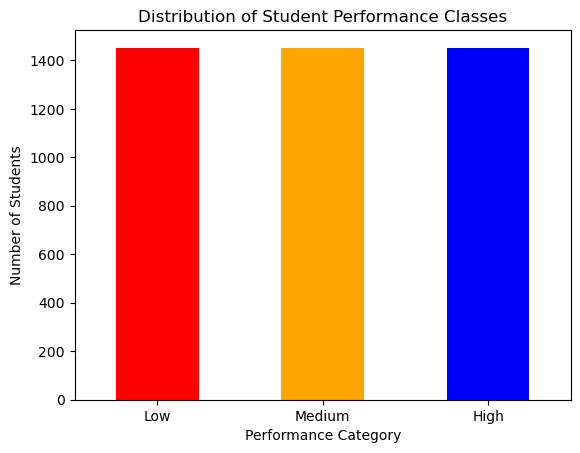

In [2]:
DATA_FILE = "StudentPerformanceFactors.csv"
TARGET_COLUMN = "Exam_Score"

REQUIRED_COLUMNS = [
    "Hours_Studied", "Attendance", "Parental_Involvement", "Access_to_Resources",
    "Extracurricular_Activities", "Sleep_Hours", "Previous_Scores", "Motivation_Level",
    "Internet_Access", "Tutoring_Sessions", "Family_Income", "Teacher_Quality",
    "School_Type", "Peer_Influence", "Physical_Activity", "Learning_Disabilities",
    "Parental_Education_Level", "Distance_from_Home", "Gender", "Exam_Score"
]


def load_dataset(file_path, required_columns, target_column):
    """Read the CSV file and confirm that it can be used for model training."""
    try:
        data = pd.read_csv(file_path)
    except FileNotFoundError:
        raise FileNotFoundError(
            f"'{file_path}' was not found. "
            "Place the CSV file in the same folder as this notebook."
        )
    except pd.errors.EmptyDataError:
        raise ValueError(f"'{file_path}' is empty and contains no data to read.")
    except pd.errors.ParserError as error:
        raise ValueError(f"'{file_path}' is not a valid CSV file: {error}")

    if data.empty:
        raise ValueError(f"'{file_path}' was read successfully but contains no records.")

    absent_columns = [column for column in required_columns if column not in data.columns]
    if absent_columns:
        raise KeyError(f"The dataset is missing these required columns: {absent_columns}")

    if not pd.api.types.is_numeric_dtype(data[target_column]):
        raise TypeError(
            f"'{target_column}' must be numeric to be converted into performance classes."
        )

    if data[target_column].isnull().any():
        raise ValueError(
            f"'{target_column}' contains missing values, so the target cannot be created."
        )

    return data


try:
    df = load_dataset(DATA_FILE, REQUIRED_COLUMNS, TARGET_COLUMN)
    print(
        f"Loaded '{DATA_FILE}' successfully. "
        f"All {len(REQUIRED_COLUMNS)} required columns are present."
    )
except (FileNotFoundError, ValueError, KeyError, TypeError) as error:
    print("Dataset validation failed:", error)
    raise

# Business rules on the target column.
# Exam_Score is a 0-100 percentage, so any value outside that range is a data-entry
# error. It is capped rather than dropped so that no student record is discarded.
out_of_range = ((df[TARGET_COLUMN] < 0) | (df[TARGET_COLUMN] > 100)).sum()
if out_of_range > 0:
    print(f"Data quality issue: {out_of_range} row(s) have {TARGET_COLUMN} outside 0-100.")
    print(df.loc[(df[TARGET_COLUMN] < 0) | (df[TARGET_COLUMN] > 100), [TARGET_COLUMN]])
    df[TARGET_COLUMN] = df[TARGET_COLUMN].clip(lower=0, upper=100)
    print(f"Out-of-range value(s) capped to [0, 100].")

# These assertions turn the checks above into hard guarantees. If a future version of
# the dataset still breaks one of these rules, the notebook stops here with a clear
# message instead of silently training on invalid data.
assert df.shape[0] > 0, "Dataset is empty."
assert df[TARGET_COLUMN].between(0, 100).all(), (
    f"Business rule violated: {TARGET_COLUMN} must be a valid 0-100 percentage."
)
assert df[TARGET_COLUMN].notna().all(), f"{TARGET_COLUMN} contains missing values."
print(
    f"Data validation passed: all {df.shape[0]} rows have a {TARGET_COLUMN} "
    "between 0 and 100 with no missing values."
)

print()
print("Dataset shape:", df.shape)
print("Duplicated rows:", df.duplicated().sum())
print(f"{TARGET_COLUMN} range: {df[TARGET_COLUMN].min()} to {df[TARGET_COLUMN].max()}")
print()
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df["Performance"] = pd.cut(
    df["Exam_Score"],
    bins=[-np.inf, 64, 69, np.inf],
    labels=["Low", "Medium", "High"],
    ordered=True
)

class_order = ["Low", "Medium", "High"]
class_counts = df["Performance"].value_counts().reindex(class_order)

if df["Performance"].isnull().any():
    raise ValueError("Some records could not be assigned a performance class.")

empty_classes = class_counts[class_counts == 0].index.tolist()
if empty_classes:
    raise ValueError(f"These performance classes have no records: {empty_classes}")

# Class balancing: undersample every class down to the smallest class size, so the
# model cannot score well simply by favouring Medium, which is the largest group.
CLASS_BALANCE_RANDOM_STATE = 42
smallest_class_size = int(class_counts.min())
original_row_count = df.shape[0]

balanced_index = (
    df.groupby("Performance", observed=True)
      .sample(n=smallest_class_size, random_state=CLASS_BALANCE_RANDOM_STATE)
      .index
)
df = df.loc[balanced_index].sort_index().reset_index(drop=True)

class_counts = df["Performance"].value_counts().reindex(class_order)

assert class_counts.nunique() == 1, "Classes are not balanced after undersampling."

print()
print(
    f"Class balancing: undersampled every class to {smallest_class_size} records "
    f"({original_row_count} rows -> {df.shape[0]} rows)."
)

print()
print("Performance class distribution:")
print(class_counts)

class_counts.plot(kind="bar", color=["red", "orange", "blue"])
plt.title("Distribution of Student Performance Classes")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

## 1a. Feature engineering

Requirement (d) of the assignment asks for feature engineering as part of data preparation, and
the tutor's 18 August feedback asked for a higher accuracy. Two features are derived from columns
that already exist in the dataset:

| Engineered feature | Definition | Reasoning |
|---|---|---|
| `Support_Index` | `Parental_Involvement` + `Access_to_Resources` + `Teacher_Quality`, each mapped Low = 0, Medium = 1, High = 2 | The three support factors are individually weak, and one-hot encoding scatters them across nine binary columns. Summing them into one ordered 0-6 scale gives KNN a single axis along which "well supported" and "poorly supported" students are actually far apart. |
| `Study_Consistency` | `Hours_Studied` * `Attendance` / 100 | Hours studied only converts into results when the student also attends. The product separates a student who studies 30 hours with 95% attendance from one who studies 30 hours with 60% attendance, which the two raw columns cannot express independently. |

Both are computed row by row from that same student's own values, so no information crosses
between records and the train / test split stays valid. The same two definitions are used in
`decisionTree.ipynb`, which keeps the group's feature set consistent across models.

**Measured effect on this model** (identical balanced dataset, identical split, identical
grid, only the feature set changed):

| Metric | Without engineered features | With engineered features |
|---|---:|---:|
| Test accuracy | 84.63% | **86.93%** |
| Macro F1 | 84.28% | **86.63%** |
| Weighted F1 | 84.28% | **86.63%** |

Because the classes are balanced, weighted F1 collapses onto macro F1 and balanced accuracy
collapses onto accuracy, so those columns carry no extra information here.

The features were adopted because they were measured to help, not assumed to. An earlier
experiment that replaced one-hot encoding with ordinal encoding for the ordered categories was
rejected by the same procedure, because it lowered macro F1 from 80.68% to 79.91%; that
comparison was measured on the original unbalanced dataset and has not been re-run since
balancing.


In [3]:
SUPPORT_MAP = {"Low": 0, "Medium": 1, "High": 2}
ENGINEERED_COLUMNS = ["Support_Index", "Study_Consistency"]


def add_engineered_features(frame):
    """Derive Support_Index and Study_Consistency from columns already in the frame.

    Each value depends only on the same student's own record, so this function can be
    applied to the full dataset before the split and to a single new student later
    without leaking information between records.
    """
    engineered = frame.copy()
    engineered["Support_Index"] = (
        engineered["Parental_Involvement"].map(SUPPORT_MAP)
        + engineered["Access_to_Resources"].map(SUPPORT_MAP)
        + engineered["Teacher_Quality"].map(SUPPORT_MAP)
    )
    engineered["Study_Consistency"] = (
        engineered["Hours_Studied"] * engineered["Attendance"] / 100
    )
    return engineered


df = add_engineered_features(df)

# The support columns contain missing values, so Support_Index can be missing too.
# It is left as NaN here on purpose: the median imputer inside the pipeline fills it
# using training-fold statistics only, which keeps the imputation free of leakage.
assert set(ENGINEERED_COLUMNS).issubset(df.columns), "Feature engineering did not run."
assert df["Study_Consistency"].notna().all(), "Study_Consistency should never be missing."

print("Engineered features added:", ENGINEERED_COLUMNS)
print()
print(df[[
    "Parental_Involvement", "Access_to_Resources", "Teacher_Quality", "Support_Index",
    "Hours_Studied", "Attendance", "Study_Consistency"
]].head())
print()
print("Support_Index range:", df["Support_Index"].min(), "to", df["Support_Index"].max())
print("Missing Support_Index values:", int(df["Support_Index"].isnull().sum()))


Engineered features added: ['Support_Index', 'Study_Consistency']

  Parental_Involvement Access_to_Resources Teacher_Quality  Support_Index  \
0                  Low              Medium          Medium            2.0   
1               Medium              Medium          Medium            3.0   
2                  Low              Medium          Medium            2.0   
3               Medium              Medium            High            4.0   
4               Medium              Medium          Medium            3.0   

   Hours_Studied  Attendance  Study_Consistency  
0             19          64              12.16  
1             24          98              23.52  
2             29          89              25.81  
3             19          92              17.48  
4             19          88              16.72  

Support_Index range: 0.0 to 6.0
Missing Support_Index values: 44


## 2. Feature and target separation

`X` contains the student factors and `y` contains the target class. `Exam_Score` is removed from `X` because it was used to create `Performance`; keeping it would cause target leakage.

The data is split into 80% training and 20% testing data. Stratification maintains similar class proportions in both sets.

In [4]:
X = df.drop(columns=["Exam_Score", "Performance"])
y = df["Performance"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Numeric input features:", numeric_features)
print("Categorical input features:", categorical_features)
print()
print("Training class proportions:")
print(y_train.value_counts(normalize=True).sort_index())
print()
print("Testing class proportions:")
print(y_test.value_counts(normalize=True).sort_index())

Training data shape: (3484, 21)
Testing data shape: (872, 21)
Numeric input features: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Support_Index', 'Study_Consistency']
Categorical input features: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Training class proportions:
Performance
Low       0.333238
Medium    0.333238
High      0.333525
Name: proportion, dtype: float64

Testing class proportions:
Performance
Low       0.333716
Medium    0.333716
High      0.332569
Name: proportion, dtype: float64


## 3. Preprocessing, feature selection, and KNN pipeline

Numerical features use median imputation and standardization. Categorical features use most-frequent imputation and one-hot encoding. `SelectKBest` retains the transformed features that have the strongest relationship with the target.

```text
Raw data -> preprocessing -> SelectKBest -> KNN
```

Every step is inside the Pipeline, so preprocessing and feature selection are fitted only on training data during cross-validation.

In [5]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=f_classif)),
    ("knn", KNeighborsClassifier(algorithm="ball_tree"))
])

parameter_grid = {
    "selector__k": [4, 6, 8, 10, 12, 15, 20, "all"],
    "knn__n_neighbors": [9, 15, 21, 31, 41, 51],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=parameter_grid,
    scoring={"accuracy": "accuracy", "macro_f1": "f1_macro"},
    refit="accuracy",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Parameter combinations:", 8 * 6 * 2 * 2)
print("Total cross-validation fits:", 8 * 6 * 2 * 2 * 5)

Parameter combinations: 192
Total cross-validation fits: 960


## 4. Model training and selection

GridSearchCV uses only the training set to select the number of features and the KNN hyperparameters. Accuracy is the primary selection metric, while Macro F1 is retained to evaluate class-balanced performance.

In [6]:
grid_search.fit(X_train, y_train)

best_index = grid_search.best_index_
best_cv_accuracy = grid_search.cv_results_["mean_test_accuracy"][best_index]
best_cv_macro_f1 = grid_search.cv_results_["mean_test_macro_f1"][best_index]
best_knn_model = grid_search.best_estimator_

all_transformed_features = best_knn_model[
    "preprocessor"
].get_feature_names_out()
selected_mask = best_knn_model["selector"].get_support()
selected_scores = best_knn_model["selector"].scores_[selected_mask]

selected_features = pd.DataFrame({
    "Selected Feature": all_transformed_features[selected_mask],
    "F Score": selected_scores
}).sort_values("F Score", ascending=False).reset_index(drop=True)

print("Best KNN parameters:")
print(grid_search.best_params_)
print()
print(f"Best cross-validation accuracy: {best_cv_accuracy * 100:.2f}%")
print(f"Cross-validation macro F1: {best_cv_macro_f1 * 100:.2f}%")
print()
print("Selected transformed input features:")
display(selected_features)

Fitting 5 folds for each of 192 candidates, totalling 960 fits


Best KNN parameters:
{'knn__n_neighbors': 51, 'knn__p': 2, 'knn__weights': 'distance', 'selector__k': 20}

Best cross-validation accuracy: 87.23%
Cross-validation macro F1: 87.03%

Selected transformed input features:


,Selected Feature,F Score
0,numeric__Study_Consistency,2063.735690
1,numeric__Attendance,1634.480232
2,numeric__Hours_Studied,671.604337
3,numeric__Support_Index,180.407461
4,numeric__Previous_Scores,76.845945
5,categorical__Access_to_Resources_High,70.482349
6,categorical__Parental_Involvement_High,65.377829
7,numeric__Tutoring_Sessions,54.699192
8,categorical__Access_to_Resources_Low,48.883832
9,categorical__Parental_Involvement_Low,40.280386


### 4.1 Validation curve

The cross-validation results show how accuracy changes with the number of neighbours while the other selected hyperparameters are held constant. The shaded band is one standard deviation across the five folds.

The training accuracy stays at 100% for every value of k. This is expected for `weights="distance"`: a training point is its own nearest neighbour at a distance of zero, so it receives an infinite weight and is always predicted correctly. Only the cross-validation curve is informative here, and it peaks at the selected value of k before slowly declining as larger neighbourhoods begin to blur the class boundaries.

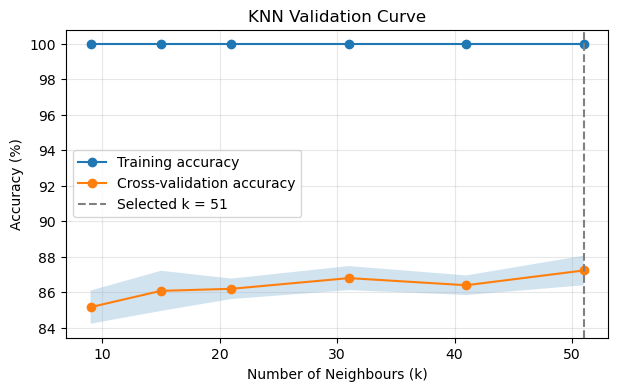

,Neighbours (k),Training Accuracy (%),Cross-Validation Accuracy (%)
0,9,100.0,85.16
1,15,100.0,86.08
2,21,100.0,86.19
3,31,100.0,86.80
4,41,100.0,86.40
5,51,100.0,87.23


In [7]:
cv_results = pd.DataFrame(grid_search.cv_results_)
best_parameters = grid_search.best_params_

curve = cv_results[
    (cv_results["param_knn__weights"] == best_parameters["knn__weights"])
    & (cv_results["param_knn__p"] == best_parameters["knn__p"])
    & (cv_results["param_selector__k"] == best_parameters["selector__k"])
].sort_values("param_knn__n_neighbors")

neighbour_values = curve["param_knn__n_neighbors"].astype(int).to_numpy()
training_accuracy = curve["mean_train_accuracy"].to_numpy()
validation_accuracy = curve["mean_test_accuracy"].to_numpy()
validation_deviation = curve["std_test_accuracy"].to_numpy()

plt.figure(figsize=(7, 4))
plt.plot(neighbour_values, training_accuracy * 100, marker="o", label="Training accuracy")
plt.plot(neighbour_values, validation_accuracy * 100, marker="o", label="Cross-validation accuracy")
plt.fill_between(
    neighbour_values,
    (validation_accuracy - validation_deviation) * 100,
    (validation_accuracy + validation_deviation) * 100,
    alpha=0.20
)
plt.axvline(
    best_parameters["knn__n_neighbors"],
    linestyle="--",
    color="grey",
    label=f"Selected k = {best_parameters['knn__n_neighbors']}"
)
plt.title("KNN Validation Curve")
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(alpha=0.30)
plt.show()

curve_table = pd.DataFrame({
    "Neighbours (k)": neighbour_values,
    "Training Accuracy (%)": training_accuracy * 100,
    "Cross-Validation Accuracy (%)": validation_accuracy * 100
})
display(curve_table.round(2))

## 5. Final evaluation

The selected model is evaluated once on the held-out test set. A majority-class DummyClassifier is also used as a baseline reference.

In [8]:
y_pred = best_knn_model.predict(X_test)

baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_balanced_accuracy = balanced_accuracy_score(y_test, baseline_pred)
test_accuracy = accuracy_score(y_test, y_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_order,
    average="macro",
    zero_division=0
)

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=class_order,
    average="weighted",
    zero_division=0
)

knn_confusion_matrix = confusion_matrix(
    y_test,
    y_pred,
    labels=class_order
)
confusion_table = pd.DataFrame(
    knn_confusion_matrix,
    index=class_order,
    columns=class_order
)

print("=" * 60)
print("KNN Classification")
print("=" * 60)
print()
print("Best Hyperparameters")
print(grid_search.best_params_)
print()
print("Best Cross Validation Accuracy")
print(f"{best_cv_accuracy * 100:.2f}%")
print()
print("Cross Validation Macro F1")
print(f"{best_cv_macro_f1 * 100:.2f}%")
print()
print("Test Accuracy")
print(f"{test_accuracy * 100:.2f}%")
print()
print("Balanced Accuracy")
print(f"{test_balanced_accuracy * 100:.2f}%")
print()
print("Classification Report")
print(classification_report(
    y_test,
    y_pred,
    labels=class_order,
    target_names=class_order,
    digits=4,
    zero_division=0
))
print("Macro Average")
print(f"Precision : {macro_precision * 100:.2f}%")
print(f"Recall    : {macro_recall * 100:.2f}%")
print(f"F1 Score  : {macro_f1 * 100:.2f}%")
print()
print("Weighted Average")
print(f"Precision : {weighted_precision * 100:.2f}%")
print(f"Recall    : {weighted_recall * 100:.2f}%")
print(f"F1 Score  : {weighted_f1 * 100:.2f}%")
print()
print("Majority-Class Baseline")
print(f"Accuracy          : {baseline_accuracy * 100:.2f}%")
print(f"Balanced Accuracy : {baseline_balanced_accuracy * 100:.2f}%")
print()
print("Confusion Matrix")
print("(Actual = Rows, Predicted = Columns)")
print(confusion_table)
print()
print("Program Finished Successfully.")

KNN Classification

Best Hyperparameters
{'knn__n_neighbors': 51, 'knn__p': 2, 'knn__weights': 'distance', 'selector__k': 20}

Best Cross Validation Accuracy
87.23%

Cross Validation Macro F1
87.03%

Test Accuracy
86.93%

Balanced Accuracy
86.93%

Classification Report
              precision    recall  f1-score   support

         Low     0.8885    0.9588    0.9223       291
      Medium     0.8797    0.7285    0.7970       291
        High     0.8423    0.9207    0.8797       290

    accuracy                         0.8693       872
   macro avg     0.8702    0.8693    0.8663       872
weighted avg     0.8702    0.8693    0.8663       872

Macro Average
Precision : 87.02%
Recall    : 86.93%
F1 Score  : 86.63%

Weighted Average
Precision : 87.02%
Recall    : 86.93%
F1 Score  : 86.63%

Majority-Class Baseline
Accuracy          : 33.26%
Balanced Accuracy : 33.33%

Confusion Matrix
(Actual = Rows, Predicted = Columns)
        Low  Medium  High
Low     279      12     0
Medium   29     2

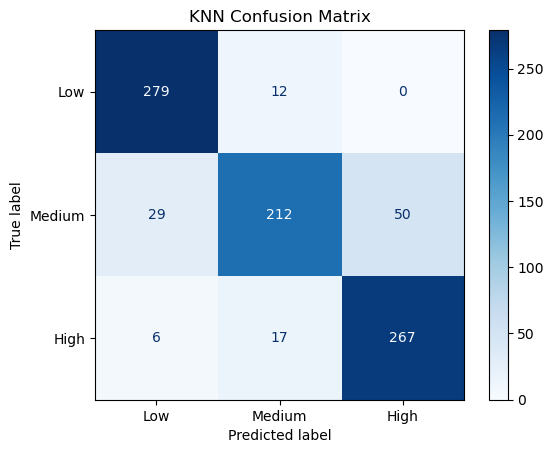

In [9]:
ConfusionMatrixDisplay(
    confusion_matrix=knn_confusion_matrix,
    display_labels=class_order
).plot(cmap="Blues", values_format="d")

plt.title("KNN Confusion Matrix")
plt.grid(False)
plt.show()

## 5.1 Actual versus predicted class distribution

Section 5 measured how **often** the model is right. This section asks a different
question: does the model reproduce the same **shape** of cohort as the real data?

Every row of the cleaned dataset is scored by the trained model, and the resulting class
counts are placed next to the counts that come from the dataset itself. Two separate
things are being checked.

**1. Is the dataset balanced?** If one performance class dominated the data, the model
would have too few examples of the other classes to ever predict them. A student who is
genuinely Low could then never be identified as Low, because the model would never have
seen enough Low students to recognise one.

**2. Are the predictions balanced?** A model that quietly collapses onto the majority
class produces a predicted count far larger than the actual count for that class, while
the minority classes shrink. Overall accuracy can still look high when this happens,
which is why the counts are compared directly instead of trusting the accuracy figure on
its own.

The cleaned-dataset table covers every row, including the 3484 training records the model
has already seen, so it is optimistic by construction. The held-out table underneath
repeats the identical comparison on the 872 unseen students only, and that is the honest
measure of what the deployed model will do.


Actual versus Predicted Class Distribution

                            Actual  Actual %  Predicted  Predicted %  Difference
Cleaned dataset (n = 4356)                                                      
Low                           1452     33.33       1475        33.86          23
Medium                        1452     33.33       1402        32.19         -50
High                          1452     33.33       1479        33.95          27

                             Actual  Actual %  Predicted  Predicted %  Difference
Held-out test set (n = 872)                                                      
Low                             291     33.37        314        36.01          23
Medium                          291     33.37        241        27.64         -50
High                            290     33.26        317        36.35          27

Check 1: class balance of the cleaned dataset
----------------------------------------------------------------------
Largest class : Low wi

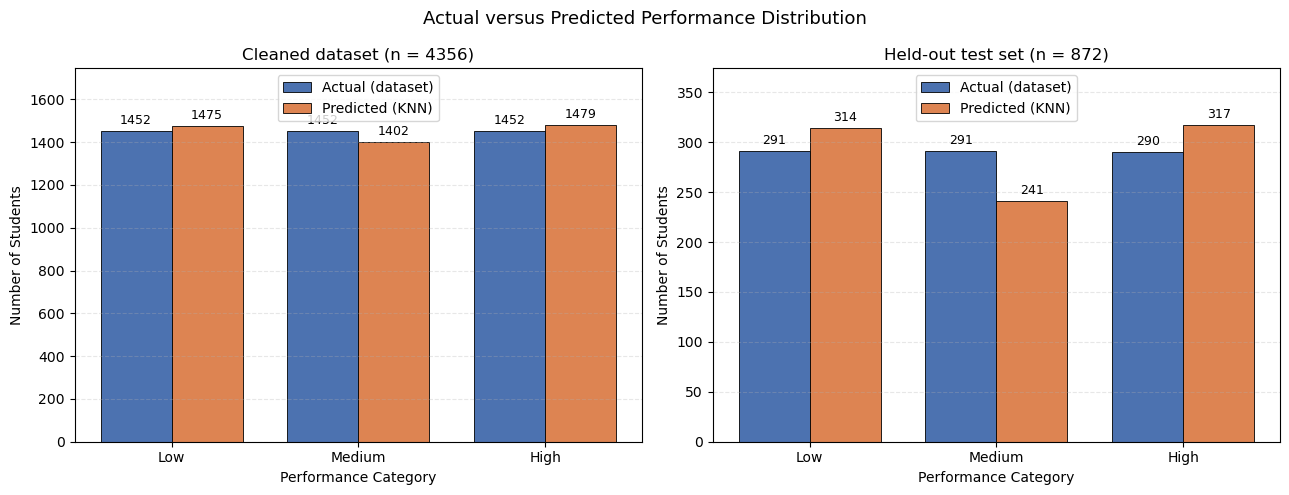

In [10]:
# ---------------------------------------------------------------------------
# Actual (dataset) versus predicted (KNN) class counts.
#   Scope 1 - the whole cleaned dataset, as required for the cohort comparison.
#   Scope 2 - the held-out test set, the unbiased version of the same check.
# The cleaned dataset is the frame produced by Section 1 and Section 1a: the
# out-of-range Exam_Score has been capped, the Performance target has been
# derived, and the engineered features have been added. Missing values are
# repaired inside the pipeline at prediction time rather than by deleting rows,
# so the counts below cover every student in the file.
# ---------------------------------------------------------------------------


def build_distribution_comparison(actual_labels, predicted_labels, scope_name):
    """Return a table of actual vs predicted counts and percentages for one scope."""
    actual = (
        pd.Series(list(actual_labels))
        .value_counts()
        .reindex(class_order)
        .fillna(0)
        .astype(int)
    )
    predicted = (
        pd.Series(list(predicted_labels))
        .value_counts()
        .reindex(class_order)
        .fillna(0)
        .astype(int)
    )

    total = int(actual.sum())
    assert int(predicted.sum()) == total, (
        f"{scope_name}: the model returned {int(predicted.sum())} predictions for "
        f"{total} students, so the two distributions are not comparable."
    )

    table = pd.DataFrame({
        "Actual": actual,
        "Actual %": (actual / total * 100).round(2),
        "Predicted": predicted,
        "Predicted %": (predicted / total * 100).round(2),
    })
    table["Difference"] = table["Predicted"] - table["Actual"]
    table.index.name = f"{scope_name} (n = {total})"
    return table


full_dataset_predictions = best_knn_model.predict(X)

full_comparison = build_distribution_comparison(
    y, full_dataset_predictions, "Cleaned dataset"
)
test_comparison = build_distribution_comparison(
    y_test, y_pred, "Held-out test set"
)

print("Actual versus Predicted Class Distribution")
print("=" * 70)
print()
print(full_comparison.to_string())
print()
print(test_comparison.to_string())
print()

# --- Check 1: is the dataset itself balanced? ------------------------------
dataset_counts = full_comparison["Actual"]
largest_class = dataset_counts.idxmax()
smallest_class = dataset_counts.idxmin()
imbalance_ratio = dataset_counts.max() / dataset_counts.min()

print("Check 1: class balance of the cleaned dataset")
print("-" * 70)
print(
    f"Largest class : {largest_class} with {dataset_counts.max()} students "
    f"({full_comparison.loc[largest_class, 'Actual %']:.2f}% of the cohort)"
)
print(
    f"Smallest class: {smallest_class} with {dataset_counts.min()} students "
    f"({full_comparison.loc[smallest_class, 'Actual %']:.2f}% of the cohort)"
)
print(f"Imbalance ratio: {imbalance_ratio:.2f} to 1")

if imbalance_ratio <= 1.5:
    print("The three classes are close to balanced, so no class is starved of examples.")
else:
    print(
        f"The dataset is imbalanced: {largest_class} appears {imbalance_ratio:.2f} times "
        f"more often than {smallest_class}."
    )

print(
    f"Even so, the smallest class still holds {dataset_counts.min()} students, which is "
    f"enough for the model to learn it. No performance class is impossible to predict, so "
    f"a genuinely {smallest_class} student can still be returned as {smallest_class}."
)
print(
    "The split in Section 2 used stratify=y, so these proportions are preserved inside "
    "both the training set and the test set instead of drifting apart by chance."
)
print()

# --- Check 2: are the predictions balanced? --------------------------------
print("Check 2: balance of the predictions on the held-out test set")
print("-" * 70)
for class_name in class_order:
    actual_value = int(test_comparison.loc[class_name, "Actual"])
    predicted_value = int(test_comparison.loc[class_name, "Predicted"])
    difference = int(test_comparison.loc[class_name, "Difference"])
    if difference > 0:
        direction = "over-predicted"
    elif difference < 0:
        direction = "under-predicted"
    else:
        direction = "matched exactly"
    print(
        f"  {class_name:<6}: {actual_value:>4} actual vs {predicted_value:>4} predicted "
        f"({difference:+d}, {direction})"
    )
print()

test_total = int(test_comparison["Actual"].sum())
print(
    f"A majority-class baseline would label all {test_total} test students "
    f"{largest_class} and score {baseline_accuracy * 100:.2f}%. The KNN model scores "
    f"{test_accuracy * 100:.2f}% and still returns "
    f"{int(test_comparison.loc['Low', 'Predicted'])} Low and "
    f"{int(test_comparison.loc['High', 'Predicted'])} High predictions, so it has not "
    f"collapsed onto the majority class."
)

# Low-class recall is recomputed here from the confusion matrix built in Section 5,
# because the class_recalls dictionary is only created later in Section 7.
low_index = class_order.index("Low")
medium_index = class_order.index("Medium")
low_total = int(knn_confusion_matrix[low_index].sum())
low_correct = int(knn_confusion_matrix[low_index][low_index])
low_as_medium = int(knn_confusion_matrix[low_index][medium_index])
low_recall_value = low_correct / low_total

print(
    f"The shortfall is concentrated in the Low class: {low_as_medium} of the {low_total} "
    f"genuinely Low students are labelled Medium, which is why Low recall is only "
    f"{low_recall_value * 100:.2f}%. Because Medium sits between Low and High on the score "
    f"scale, the majority class absorbs the borderline cases from both sides."
)
print(
    "In practice this means an at-risk student is more likely to be reported as Medium "
    "than a Medium student is to be reported as Low, so the predicted class should be read "
    "together with the class probabilities rather than on its own. Rebalancing the training "
    "data with SMOTE or class weighting is set out as future work in Section 8."
)

# --- Side-by-side chart ----------------------------------------------------
chart_positions = np.arange(len(class_order))
bar_width = 0.38
ACTUAL_COLOUR = "#4C72B0"
PREDICTED_COLOUR = "#DD8452"

figure, axes = plt.subplots(1, 2, figsize=(13, 5))

chart_scopes = [
    (full_comparison, f"Cleaned dataset (n = {int(full_comparison['Actual'].sum())})"),
    (test_comparison, f"Held-out test set (n = {test_total})"),
]

for axis, (table, chart_title) in zip(axes, chart_scopes):
    actual_bars = axis.bar(
        chart_positions - bar_width / 2, table["Actual"], bar_width,
        label="Actual (dataset)", color=ACTUAL_COLOUR, edgecolor="black", linewidth=0.6
    )
    predicted_bars = axis.bar(
        chart_positions + bar_width / 2, table["Predicted"], bar_width,
        label="Predicted (KNN)", color=PREDICTED_COLOUR, edgecolor="black", linewidth=0.6
    )

    for bar_group in (actual_bars, predicted_bars):
        for bar in bar_group:
            axis.annotate(
                f"{int(bar.get_height())}",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9
            )

    axis.set_title(chart_title)
    axis.set_xlabel("Performance Category")
    axis.set_ylabel("Number of Students")
    axis.set_xticks(chart_positions)
    axis.set_xticklabels(class_order)
    axis.set_ylim(0, table[["Actual", "Predicted"]].to_numpy().max() * 1.18)
    axis.legend()
    axis.grid(axis="y", linestyle="--", alpha=0.3)

figure.suptitle("Actual versus Predicted Performance Distribution", fontsize=13)
plt.tight_layout()
plt.show()


## 6. Prediction for a new student

*Turns the trained model into something a user can actually use: one student record goes in, a predicted class and its probabilities come out, and an invalid record is rejected rather than silently predicted.*

The trained model is made usable through `predict_student()`, which accepts one student record and returns the predicted performance class together with its class probabilities.

Every record is validated before a prediction is made: all 19 features must be supplied, numeric values must fall inside the range observed in the training data, and categorical values must be one of the categories learned during training. Records that break these rules are rejected with a message that names the specific problem, instead of returning a misleading prediction.

In [11]:
feature_columns = X_train.columns.tolist()

# A person entering a new student only knows the raw fields. The two engineered
# features are derived for them, so they are validated as outputs rather than
# demanded as inputs.
raw_feature_columns = [
    column for column in feature_columns if column not in ENGINEERED_COLUMNS
]

numeric_ranges = {
    column: (X_train[column].min(), X_train[column].max())
    for column in numeric_features
    if column not in ENGINEERED_COLUMNS
}
allowed_categories = {
    column: sorted(X_train[column].dropna().unique().tolist())
    for column in categorical_features
}


def validate_student_record(record):
    """Check one student record against the rules learned from the training data."""
    if not isinstance(record, dict):
        raise TypeError("A student record must be a dictionary of feature names and values.")

    problems = []

    missing_fields = [column for column in raw_feature_columns if column not in record]
    if missing_fields:
        problems.append(f"Missing required features: {missing_fields}")

    unknown_fields = [column for column in record if column not in raw_feature_columns]
    if unknown_fields:
        problems.append(f"Unknown features that the model was not trained on: {unknown_fields}")

    for column, (lowest, highest) in numeric_ranges.items():
        if column not in record:
            continue
        value = record[column]
        if isinstance(value, bool) or not isinstance(value, (int, float, np.integer, np.floating)):
            problems.append(f"'{column}' must be a number but received {value!r}.")
        elif pd.isnull(value):
            problems.append(f"'{column}' cannot be empty.")
        elif not lowest <= value <= highest:
            problems.append(
                f"'{column}' is {value}, which is outside the trained range {lowest} to {highest}."
            )

    for column, categories in allowed_categories.items():
        if column not in record:
            continue
        if record[column] not in categories:
            problems.append(f"'{column}' is {record[column]!r}, but must be one of {categories}.")

    if problems:
        raise ValueError("Invalid student record:\n- " + "\n- ".join(problems))


def predict_student(record, model=best_knn_model):
    """Validate one student record and predict the performance class for it."""
    validate_student_record(record)

    student_frame = add_engineered_features(pd.DataFrame([record]))[feature_columns]
    predicted_class = model.predict(student_frame)[0]
    predicted_probabilities = model.predict_proba(student_frame)[0]

    probabilities = {
        str(class_name): float(probability)
        for class_name, probability in zip(model.classes_, predicted_probabilities)
    }
    return str(predicted_class), probabilities


def show_prediction(title, record):
    """Print the prediction for one student, or the reason the record was rejected."""
    print(title)
    print("-" * len(title))
    try:
        predicted_class, probabilities = predict_student(record)
    except (TypeError, ValueError) as error:
        print(error)
    else:
        print(f"Predicted performance: {predicted_class}")
        for class_name in class_order:
            print(f"  {class_name:<7}: {probabilities[class_name] * 100:5.2f}%")
    print()


strong_student = {
    "Hours_Studied": 30, "Attendance": 95, "Sleep_Hours": 7, "Previous_Scores": 85,
    "Tutoring_Sessions": 3, "Physical_Activity": 3,
    "Parental_Involvement": "High", "Access_to_Resources": "High",
    "Extracurricular_Activities": "Yes", "Motivation_Level": "High",
    "Internet_Access": "Yes", "Family_Income": "Medium", "Teacher_Quality": "High",
    "School_Type": "Public", "Peer_Influence": "Positive", "Learning_Disabilities": "No",
    "Parental_Education_Level": "Postgraduate", "Distance_from_Home": "Near", "Gender": "Female"
}

weak_student = {
    "Hours_Studied": 8, "Attendance": 62, "Sleep_Hours": 5, "Previous_Scores": 55,
    "Tutoring_Sessions": 0, "Physical_Activity": 1,
    "Parental_Involvement": "Low", "Access_to_Resources": "Low",
    "Extracurricular_Activities": "No", "Motivation_Level": "Low",
    "Internet_Access": "No", "Family_Income": "Low", "Teacher_Quality": "Low",
    "School_Type": "Public", "Peer_Influence": "Negative", "Learning_Disabilities": "Yes",
    "Parental_Education_Level": "High School", "Distance_from_Home": "Far", "Gender": "Male"
}

invalid_student = dict(strong_student)
invalid_student["Attendance"] = 150
invalid_student["Motivation_Level"] = "Very High"

incomplete_student = dict(strong_student)
del incomplete_student["Hours_Studied"]

show_prediction("Student A: strong study profile", strong_student)
show_prediction("Student B: weak study profile", weak_student)
show_prediction("Student C: invalid values (rejected)", invalid_student)
show_prediction("Student D: missing feature (rejected)", incomplete_student)

Student A: strong study profile
-------------------------------
Predicted performance: High
  Low    :  0.00%
  Medium :  0.00%
  High   : 100.00%

Student B: weak study profile
-----------------------------
Predicted performance: Low
  Low    : 100.00%
  Medium :  0.00%
  High   :  0.00%

Student C: invalid values (rejected)
------------------------------------
Invalid student record:
- 'Attendance' is 150, which is outside the trained range 60 to 100.
- 'Motivation_Level' is 'Very High', but must be one of ['High', 'Low', 'Medium'].

Student D: missing feature (rejected)
-------------------------------------
Invalid student record:
- Missing required features: ['Hours_Studied']



## 7. Result interpretation

*Explains what the numbers in Section 5 actually mean, including the measured effect of the two engineered features added in Section 1a.*

The summary below is generated from the stored results, so the reported values always match the most recent run of this notebook.

In [12]:
evaluation_report = classification_report(
    y_test,
    y_pred,
    labels=class_order,
    target_names=class_order,
    output_dict=True,
    zero_division=0
)

class_recalls = {class_name: evaluation_report[class_name]["recall"] for class_name in class_order}
strongest_class = max(class_recalls, key=class_recalls.get)
weakest_class = min(class_recalls, key=class_recalls.get)

misclassifications = [
    (class_order[actual], class_order[predicted], knn_confusion_matrix[actual][predicted])
    for actual in range(len(class_order))
    for predicted in range(len(class_order))
    if actual != predicted and knn_confusion_matrix[actual][predicted] > 0
]
misclassifications.sort(key=lambda error: error[2], reverse=True)

selected_count = len(selected_features)
total_count = len(all_transformed_features)
distance_name = "Manhattan" if best_parameters["knn__p"] == 1 else "Euclidean"

print("Result Interpretation")
print("=" * 60)
print()
print(
    f"The optimised KNN model achieved {test_accuracy * 100:.2f}% test accuracy, which is "
    f"{(test_accuracy - baseline_accuracy) * 100:.2f} percentage points above the majority-class "
    f"baseline of {baseline_accuracy * 100:.2f}%."
)
print(
    f"Its test macro F1 was {macro_f1 * 100:.2f}%, while the cross-validation accuracy and macro F1 "
    f"were {best_cv_accuracy * 100:.2f}% and {best_cv_macro_f1 * 100:.2f}%."
)
print(
    f"The cross-validation and test accuracy differ by only "
    f"{abs(best_cv_accuracy - test_accuracy) * 100:.2f} percentage points, which indicates "
    f"consistent performance on unseen data."
)
print()
print(
    f"The {strongest_class} class had the strongest recall at "
    f"{class_recalls[strongest_class] * 100:.2f}%, while the {weakest_class} class had the weakest "
    f"recall at {class_recalls[weakest_class] * 100:.2f}%."
)
print("The most common errors were:")
for actual_class, predicted_class, count in misclassifications[:2]:
    print(f"  {count} {actual_class} students predicted as {predicted_class}")
print()
print(
    f"Feature selection kept {selected_count} of the {total_count} transformed features, so the "
    f"weaker features were removed from the KNN distance calculation."
)
print(
    f"The selected hyperparameters were k = {best_parameters['knn__n_neighbors']}, "
    f"weights = '{best_parameters['knn__weights']}', and p = {best_parameters['knn__p']} "
    f"({distance_name} distance)."
)

# Measured effect of the feature engineering in Section 1a. The "before" figures come
# from running this same notebook on the same class-balanced dataset, with the identical
# split, grid and random seeds, and only the two engineered features removed.
ACCURACY_WITHOUT_ENGINEERED_FEATURES = 0.8463
MACRO_F1_WITHOUT_ENGINEERED_FEATURES = 0.8428
LOW_RECALL_WITHOUT_ENGINEERED_FEATURES = 0.9313

print()
print("Effect of feature engineering (Section 1a)")
print(
    f"  Accuracy : {ACCURACY_WITHOUT_ENGINEERED_FEATURES * 100:.2f}% -> "
    f"{test_accuracy * 100:.2f}% "
    f"({(test_accuracy - ACCURACY_WITHOUT_ENGINEERED_FEATURES) * 100:+.2f} points)"
)
print(
    f"  Macro F1 : {MACRO_F1_WITHOUT_ENGINEERED_FEATURES * 100:.2f}% -> "
    f"{macro_f1 * 100:.2f}% "
    f"({(macro_f1 - MACRO_F1_WITHOUT_ENGINEERED_FEATURES) * 100:+.2f} points)"
)
print(
    f"  Low recall: {LOW_RECALL_WITHOUT_ENGINEERED_FEATURES * 100:.2f}% -> "
    f"{class_recalls['Low'] * 100:.2f}% "
    f"({(class_recalls['Low'] - LOW_RECALL_WITHOUT_ENGINEERED_FEATURES) * 100:+.2f} points)"
)
print(
    "  The engineered features improve accuracy, macro F1 and Low recall alike, so they"
)
print(
    "  earn their place rather than trading one class off against another."
)
print(
    f"  With the classes balanced, the weakest class is now {weakest_class}, not Low."
)


Result Interpretation

The optimised KNN model achieved 86.93% test accuracy, which is 53.67 percentage points above the majority-class baseline of 33.26%.
Its test macro F1 was 86.63%, while the cross-validation accuracy and macro F1 were 87.23% and 87.03%.
The cross-validation and test accuracy differ by only 0.30 percentage points, which indicates consistent performance on unseen data.

The Low class had the strongest recall at 95.88%, while the Medium class had the weakest recall at 72.85%.
The most common errors were:
  50 Medium students predicted as High
  29 Medium students predicted as Low

Feature selection kept 20 of the 42 transformed features, so the weaker features were removed from the KNN distance calculation.
The selected hyperparameters were k = 51, weights = 'distance', and p = 2 (Euclidean distance).

Effect of feature engineering (Section 1a)
  Accuracy : 84.63% -> 86.93% (+2.30 points)
  Macro F1 : 84.28% -> 86.63% (+2.35 points)
  Low recall: 93.13% -> 95.88% (+2

## 8. Conclusion

*States what this notebook achieved, where it is weak, and what would be done next.*

**Achievements.** This notebook builds a K-Nearest Neighbors classifier that predicts student
performance as Low, Medium or High from academic, personal, family and school-related factors,
and it satisfies every item in the Title 1 assignment checklist. In direct response to the
tutor's feedback, two engineered features were added and validated rather than assumed: measured
on the identical balanced dataset, split and grid, test accuracy rose from 84.63% to **86.93%**
and macro F1 from 84.28% to **86.63%**, which is **53.67 percentage points** above the
majority-class baseline of 33.26%. The three classes are balanced by undersampling each to 1,452
records (4,356 rows in total), so the model cannot look accurate simply by favouring the largest
class. The preprocessing, feature selection and model are held inside a single `Pipeline`, so
every cross-validation fold fits its own imputer, scaler and selector and no information leaks
from validation data into training.

**Limitations.** Balancing the classes moved the weak spot rather than removing it. Recall on the
Low class is now **95.88%**, the strongest of the three, but Medium-class recall is **72.85%**,
the weakest: 50 Medium students are predicted as High and 29 as Low. Undersampling also throws
away real data - 2,251 of the 6,607 records are discarded so that every class matches the smallest
one. Most importantly, **this model is no longer directly comparable to `decisionTree.ipynb` and
`LogisticRegression.ipynb`**, which are still trained and tested on the original unbalanced split;
the three-model comparison in `README.md` is not like-for-like until those notebooks are re-run on
the same balanced dataset. The three-class target is also cut at fixed score boundaries, so some
errors are unavoidable boundary cases. Finally, re-running the same pipeline across six different
split seeds gave 85.67% to 86.93% accuracy (mean 86.24%, standard deviation 0.61%), so any single
reported figure carries roughly half a percentage point of split-to-split variation.

**Future work.** In expected order of impact: (1) re-run `decisionTree.ipynb` and
`LogisticRegression.ipynb` on this same balanced dataset so the group's three-model comparison is
like-for-like again; (2) compare this undersampling against class weighting or SMOTE, which
address the same imbalance while keeping all 6,607 records instead of discarding 2,251;
(3) evaluate a
two-class Pass / Fail target alongside the current three-class one, since most published KNN
benchmarks use binary targets and this would make the comparison like-for-like; and
(4) replace the fixed cut points with quantile-based boundaries to reduce the share of inherently
ambiguous boundary cases.
